# Search Results → AnnData

Converts raw DIANN output into [AnnData](https://anndata.readthedocs.io) objects for downstream analysis. This is the second step in the data-object creation pipeline (run after `01_metadata.ipynb`).

**Inputs**
- DIANN parquet files — contains DIANN search results for all samples but the Quantitative QC mixtures
- DIANN parquet files for the QCs — quantitative QC mixture runs (one per plate)
- `metadata.parquet` — sample-level annotations produced by `01_metadata.ipynb`

To create AnnData objects for either the first or second pass of the DIANN-results (or even the DIANN version), the paths at **RESULT_PATH** and **QC_PATHS** should be changed towards the correct input paths, as well as the **ANNDATA_OUT** to where you want to store the AnnData objects.

**Outputs** (written to `Data/AnnData/DIANN`)
| File | Description |
|---|---|
| `adata_precursor.h5ad` | Precursor-level quantification, human samples |
| `adata_protein.h5ad` | Protein-level quantification, human samples |
| `adata_precursor_qc.h5ad` | Precursor-level quantification, QC mixtures |
| `adata_protein_qc.h5ad` | Protein-level quantification, QC mixtures |


The outputs are also stored in the [Zenodo](https://doi.org/10.5281/zenodo.21181080) folder at `./Data/AnnData/DIANN/`

> Do NOT override anything from the ZENODO folder since the AnnData objects also include results collected from later notebooks.

---

## Imports

In [ ]:
import os
from tqdm import tqdm
import pandas as pd
import numpy as np
from pathlib import Path
from glob import glob
import seaborn as sns
import matplotlib.pyplot as plt

from SCI_py.data.parse import df_to_anndata, align_obs_across_anndata, replace_zeros_with_nan
from SCI_py.data.read import load_spectronaut, load_diann

tqdm.pandas()

## 0. Path Configuration

### Output paths

Resolved path relative to the notebook location. Override with the `SCI_DATA_DIR` environment variable when running outside the default directory structure or if the output data is stored elsewhere.

In [28]:
NOTEBOOK_DIR = Path().resolve()
ROOT_OUT     = NOTEBOOK_DIR / "../../Data"
ROOT_OUT     = ROOT_OUT.resolve()
ROOT_OUT.mkdir(parents=True, exist_ok=True)

# Allow user override via environment variable
ROOT_OUT = Path(os.environ.get("SCI_DATA_DIR", ROOT_OUT))

ROOT_OUT.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {ROOT_OUT}")

Output directory: /home/sam/SCI/SCI/Data


### Input paths

Points to the DIANN result files and the metadata parquet generated by the previous notebook. A warning is printed if the metadata file or any of the result files are missing, as the merge step will fail without it.

- DIANN result files are available [here](https://doi.org/10.5281/zenodo.21181080)
- Metadata file: Generate in `01_metadata.ipynb` or get from [Zenodo](https://doi.org/10.5281/zenodo.21181080) in the ./Data/metadata folder.

In [38]:
# Search results of DIANN are available on Zenodo
ZENODO_FOLDER = "/public/conode53/sam/SCI_paper/Zenodo"

RESULT_PATH = glob(
    os.path.join(
        ZENODO_FOLDER,
        "search_results",
        "Human",
        "DIANN",
        '*',
        'DIANN_2.6',
        # Change path to switch between MBR and firstpass
        # 'report-first-pass.parquet'
        'report.parquet'
    )
)

# For the quantitative QCs run separately
QC_PATHS = glob(
    os.path.join(
        ZENODO_FOLDER,
        'search_results',
        'Mixture',
        'DIANN',
        '*',
        # Change path to switch between MBR and firstpass
        # 'report-first-pass.parquet'
        'report.parquet'
    )
)

# For the metadata file generated in previous notebook
METADATA_PATH = os.path.join(
    ROOT_OUT,
    'metadata',
    'metadata.parquet'
)


# Path checks
if len(RESULT_PATH)==0:
    print("Warning: Check RESULT_PATH. No paths found.")
if len(QC_PATHS)==0:
    print("Warning: Check QC_PATHS. No paths found.")

if not os.path.exists(METADATA_PATH):
    print("Warning: Run 01_metadata.ipynb first or change the METADATA_PATH variable.")
    
for RESULT_PATH_ in RESULT_PATH:
    if not os.path.exists(RESULT_PATH_):
        print("Warning: Edit RESULT_PATH so it points to the correct location of the DIANN results file.")
    
for QC_PATH in QC_PATHS:
    if not os.path.exists(QC_PATH):
        print("Warning: Edit QC_PATHS so it points to the correct location of the Quant QC directory.")

## 1. Load Data

Parse DIANN reports and join them with sample metadata. The loading function standardises modification notation to UNIMOD format and constructs a canonical precursor ID (`PrecursorIon`) used as the feature index at the precursor level.

### 1.1. Search Results

`load_diann` reads the DIA-NN results file and applies a couple of preprocessing steps:
1. **Institute / plate ID** — extracted from the raw filename via `get_institute`.
2. **Sample name** — converted to a canonical lowercase identifier using site-specific `FILENAME_CONVERTERS`.
3. **Modification notation** — DIA-NN labels (`(UniMod:1)`, etc.) are mapped to UNIMOD accessions for interoperability (`[UNIMOD:1]`, etc.).

#### 1.1.1. Human samples (+ blanks)

Main SCI dataset: A report.parquet file for each plate. DIA-NN was run on each plate independently including all samples with only human content, i.e., single-cell samples, Hela QCs, blanks and processing controls. The inclusion of specific files can have an influence on both the quantification and identifications of these samples when match-between-runs is turned on. With this setting, a spectral library is generated from the results of the first pass (searching against a predicted library of all precursors specified in the FASTA and search space related settings).

You can experiment with creating other spectral libraries (either by subsetting certain files, using different search space related settings, or creating an empirical spectral library from a different set of experiments) to see the influence of these settings on the results. In notebook `2_DatasetStatistics/00_SearchEngineComparison.ipynb`, a simple comparison is performed between DIA-NN version 2.2, 2.6, with and without match-between-runs settings and results from Spectronaut (version 20). This notebook can be considered a starting point for future explorations for comparing different search engines and search settings.

For a more systematic benchmark of quantification workflows, see `1_QCQuant` folder and related notebooks. This will later be made public in [ProteoBench](https://proteobench.cubimed.rub.de/)

In [30]:
# For plate-by-plate results
report_list = []
for SC_PATH in tqdm(RESULT_PATH):
    sc = load_diann(SC_PATH)
    report_list.append(sc)
report = pd.concat(report_list, ignore_index=True)

100%|██████████| 9/9 [05:46<00:00, 38.51s/it]


#### 1.1.2. Quantitative QC (mixtures)

Each site ran a set of mixture-based QC samples independently (one DIA-NN export per site, stored under `QC_Quant/`). These are parsed with the same loader and concatenated into a single dataframe for joint analysis.

In `1_QCQuant`, these samples are used to explore the differences between search engines and search settings. The known mixture ratio's are used as ground-truths on the quantification aspect. Note that for the identification aspect, entrapment experiments could serve as a better evaluation strategy. Note that the insights covered from these mixture samples are not necessarily directly translatable to the single-cell case.

In [39]:
qc_list = []
for QC_PATH in tqdm(QC_PATHS):
    qc = load_diann(QC_PATH)
    qc_list.append(qc)
report_qc = pd.concat(qc_list, ignore_index=True)

100%|██████████| 9/9 [00:35<00:00,  3.96s/it]


### 1.2. Merge with Metadata

Join search results with sample-level metadata on `plate_id` + `sample_name`. This attaches morphological measurements (diameter, circularity, …), experimental annotations (gradient time, plate arrival), and quality flags (doublet, dying, …) to every quantified precursor row.

In [40]:
metadata = pd.read_parquet(
    METADATA_PATH
)

df = report.merge(metadata, on=['plate_id', 'sample_name'])
df_qc = report_qc.merge(metadata, on=['plate_id', 'sample_name'])

print(df.shape)
print(df_qc.shape)

(22089865, 151)
(2466492, 151)


### 1.3. Subdivide Columns

Partition the merged dataframe columns into logical groups before pivoting to AnnData. This makes the mapping to AnnData slots explicit:

| Group | AnnData slot | Purpose |
|---|---|---|
| `cols_protpept_metadata` + `cols_idconf` + `cols_peptfeatures` | `adata.var` | Feature-level annotations |
| `cols_metadata` | `adata.obs` | Sample-level annotations |
| `cols_quant` | `adata.X` (via pivot) | Quantitative intensities |

Only the columns used downstream are retained, reducing memory footprint before the pivot.

In [41]:
# Identity / annotation columns (var-side metadata)
cols_protpept_metadata = [
    'Protein.Group',        # ~ PG.ProteinGroups
    'Protein.Ids',          # ~ PG.ProteinAccessions
    'Protein.Names',
    'Genes',
    'Stripped.Sequence',    # ~ PEP.StrippedSequence
    'Proteotypic',          # ~ PEP.IsProteotypic
    'Modified.Sequence',    # ~ EG.ModifiedSequence
    'PrecursorIon',
    'Precursor.Charge',     # ~ FG.Charge
    'Precursor.Id',         # ~ FG.PrecursorIon (precursor-level unique key)
    'Precursor.Mz',
    'Decoy',
]

# Confidence / Q-value columns
cols_idconf = [
    'Q.Value',                  # ~ FG.Qvalue (precursor-level run-specific)
    'Global.Q.Value',           # ~ EG.GlobalPrecursorQvalue
    'Lib.Q.Value',
    'PEP',
    'Peptidoform.Q.Value',
    'Global.Peptidoform.Q.Value',
    'PG.Q.Value',               # ~ PG.Qvalue
    'PG.PEP',
    'Global.PG.Q.Value',
    'Protein.Q.Value',
    'GG.Q.Value',
    'Channel.Q.Value',
    'Translated.Q.Value',
]

# Quantitative columns
cols_quant = [
    'Precursor.Quantity',       # ~ FG.Quantity / EG.TotalQuantity
    'Precursor.Normalised',
    'Ms1.Area',
    'Ms1.Normalised',
    'Ms1.Apex.Area',
    'PG.MaxLFQ',                # ~ PG.Quantity (the usual protein-level summary)
    'PG.TopN',
    'Genes.MaxLFQ',
    'Genes.MaxLFQ.Unique',
    'Genes.TopN',
    'Normalisation.Factor',
]

# Per-precursor feature columns (extraction / RT / IM / shape diagnostics)
cols_peptfeatures = [
    # Retention time
    'RT',                       # ~ EG.ApexRT
    'iRT',                      # ~ EG.iRTEmpirical
    'Predicted.RT',             # ~ EG.RTPredicted
    'Predicted.iRT',            # ~ EG.iRTPredicted
    'RT.Start',
    'RT.Stop',
    'FWHM',

    # Ion mobility (timsTOF)
    'IM',
    'iIM',
    'Predicted.IM',
    'Predicted.iIM',

    # MS1 / MS2 quality features
    'Ms1.Profile.Corr',
    'Ms1.Apex.Mz.Delta',
    'Ms1.Total.Signal.Before',
    'Ms1.Total.Signal.After',
    'Evidence',                 # closest analog to FG.CScore (DIA-NN's discriminant score)
    'Mass.Evidence',
    'Channel.Evidence',
    'Quantity.Quality',
    'Empirical.Quality',
    'Normalisation.Noise',
    'PG.MaxLFQ.Quality',
    'Genes.MaxLFQ.Quality',
    'Best.Fr.Mz',
    'Best.Fr.Mz.Delta',
]

cols_metadata = [
    'Run',
    'sample_name',
    'plate_id',
    'plate_idx',
    'source name',
    'comment[X position]',
    'comment[Y position]',
    'comment[Plate Number]',
    'comment[Gradient time]',
    'comment[thawing timepoint]',
    'comment[plate arrival]',
    'injection_order',
    'institute_name',
    'Reinjection',
    'Diameter',
    'Elongation',
    'Circularity',
    'Doublet',
    'Dividing',
    'Dying',
    'CellInBlank',
    'comment[plate arrival]_date',
    'comment[plate arrival]_time', 'comment[plate arrival]_datetime',
    'comment[Gradient time]_date', 'comment[Gradient time]_time',
    'comment[Gradient time]_datetime', 'instrument_type'
]

col_sample_index = ['sample_id']

var_cols = cols_protpept_metadata + cols_idconf + cols_peptfeatures

In [42]:
df = df.loc[
    :,
    (
        cols_protpept_metadata +
        col_sample_index +
        cols_idconf +
        cols_quant +
        cols_peptfeatures +
        cols_metadata
    )
]

df_qc = df_qc.loc[
    :,
    (
        cols_protpept_metadata +
        col_sample_index +
        cols_idconf +
        cols_quant +
        cols_peptfeatures +
        cols_metadata
    )
]

## 2. Create AnnData Objects

Pivot the long-format dataframes into AnnData's `obs × var` matrix layout. Precursor and protein objects are built separately because they use different feature indices (`PrecursorIon` vs `Protein.Group`) and different quantification columns.

### 2.1. Parse Dataframe to AnnData

`df_to_anndata` pivots the long-format report into a sparse `obs × var` intensity matrix (`adata.X`). `align_obs_across_anndata` then ensures the precursor and protein objects share an identical observation index — required for any joint analysis or cross-level comparisons later. In other words, this makes it possible to apply a boolean sample filter, prepared with the precursor AnnData object to the protein Anndata object.

In [43]:
sample_col = 'sample_id'   # or 'Run'
var_cols = cols_protpept_metadata + cols_idconf + cols_peptfeatures

# Precursor-level AnnData
adata_precursor, X_precursor = df_to_anndata(
    df,
    feature_col = 'PrecursorIon',
    value_col   = 'Precursor.Quantity',
    sample_col  = sample_col,
    obs_cols    = cols_metadata,
    var_cols    = var_cols,
)

# Protein-group-level AnnData
adata_protein, X_protein = df_to_anndata(
    df,
    feature_col = 'Protein.Group',
    value_col   = 'PG.MaxLFQ',
    sample_col  = sample_col,
    obs_cols    = cols_metadata,
    var_cols    = ['Protein.Group', 'Protein.Ids', 'Protein.Names', 'Genes'],
)

# Layers for precursor AnnData
precursor_layers = [
    'Precursor.Normalised',
    'Ms1.Area',
    'Ms1.Normalised',
    'Ms1.Apex.Area',
    'Q.Value',
    'PEP',
    'Evidence',
    'Quantity.Quality',
    'Empirical.Quality',
    'Ms1.Profile.Corr',
    'RT',
    'IM',
    'FWHM',
]
for layer_info in tqdm(precursor_layers, desc='Adding layers to precursor AnnData...'):
    adata_layer, X_layer = df_to_anndata(
        df,
        feature_col = 'PrecursorIon',
        value_col   = layer_info,
        sample_col  = sample_col,
        obs_cols    = cols_metadata,
        var_cols    = var_cols,
    )
    adata_precursor, adata_layer = align_obs_across_anndata(
        adata_precursor, X_precursor, adata_layer, X_layer
    )
    adata_precursor.layers[layer_info] = adata_layer.X

# Layers for protein AnnData
protein_layers = [
    'PG.TopN',
    'PG.Q.Value',
    'PG.PEP',
    'Global.PG.Q.Value',
    # 'Protein.Q.Value',
    'PG.MaxLFQ.Quality',
]
for layer_info in tqdm(protein_layers, desc='Adding layers to protein AnnData...'):
    adata_layer, X_layer = df_to_anndata(
        df,
        feature_col = 'Protein.Group',
        value_col   = layer_info,
        sample_col  = sample_col,
        obs_cols    = cols_metadata,
        var_cols    = ['Protein.Group', 'Protein.Ids', 'Protein.Names', 'Genes'],
    )
    adata_protein, adata_layer = align_obs_across_anndata(
        adata_protein, X_protein, adata_layer, X_layer
    )
    adata_protein.layers[layer_info] = adata_layer.X

# Align samples across the two AnnData objects
adata_precursor, adata_protein = align_obs_across_anndata(
    adata_precursor, X_precursor, adata_protein, X_protein
)

Adding layers to protein AnnData...: 100%|██████████| 5/5 [01:42<00:00, 20.57s/it]


Quantitative QC mixture samples are collected in a separate object.

In [44]:
adata_precursor_qc, X_precursor_qc = df_to_anndata(
    df_qc,
    feature_col = 'PrecursorIon',
    value_col   = layer_info,
    sample_col  = sample_col,
    obs_cols    = cols_metadata,
    var_cols    = var_cols,
)

adata_protein_qc, X_protein_qc = df_to_anndata(
    df_qc,
    feature_col = 'Protein.Group',
    value_col   = layer_info,
    sample_col  = sample_col,
    obs_cols    = cols_metadata,
    var_cols    = ['Protein.Group', 'Protein.Ids', 'Protein.Names', 'Genes'],
)

adata_precursor_qc, adata_protein_qc = align_obs_across_anndata(
    adata_precursor_qc,
    X_precursor_qc,
    adata_protein_qc,
    X_protein_qc
)

### 2.2. Add Log-Normalised Layers

Store a `log2`-transformed copy of the raw intensities as a separate layer (`X_log2`). The raw intensities are kept in `adata.X` so both scales are available without recomputation. Log-transformation is applied before saving because most downstream statistical and visualisation steps operate on the log scale.

In [45]:
import numpy as np
from scipy.sparse import issparse


def replace_zeros_with_nan(adata, layer=None, dtype=np.float32, verbose=True):
    """Replace zeros with NaN in an AnnData matrix.

    Parameters
    ----------
    adata : AnnData
        The AnnData object to modify in place.
    layer : str, optional
        Name of the layer to modify. If None, operates on `adata.X`.
    dtype : numpy dtype, default np.float32
        Float dtype to cast the result to. Must support NaN.
    verbose : bool, default True
        Whether to print the number of zeros replaced.

    Returns
    -------
    AnnData
        The same AnnData object, modified in place.
    """
    X = adata.layers[layer] if layer is not None else adata.X

    if issparse(X):
        X = X.toarray()
    else:
        X = np.asarray(X).copy()

    n_zeros = int((X == 0).sum())
    n_total = X.size

    if verbose:
        target = f"layers['{layer}']" if layer is not None else "X"
        print(
            f"Replacing {n_zeros} zeros out of {n_total} values in {target} "
            f"({100 * n_zeros / n_total:.2f}%)"
        )

    X = X.astype(dtype, copy=False)
    X[X == 0] = np.nan

    if layer is not None:
        adata.layers[layer] = X
    else:
        adata.X = X

    return adata

adata_precursor = replace_zeros_with_nan(adata_precursor)
adata_protein = replace_zeros_with_nan(adata_protein)
adata_precursor_qc =replace_zeros_with_nan(adata_precursor_qc)
adata_protein_qc = replace_zeros_with_nan(adata_protein_qc)

Replacing 4 zeros out of 233786640 values in X (0.00%)
Replacing 2462 zeros out of 19027312 values in X (0.01%)
Replacing 1352 zeros out of 8413063 values in X (0.02%)
Replacing 1215 zeros out of 1385547 values in X (0.09%)


In [46]:
adata_precursor.layers['X_log2'] = np.log2(adata_precursor.X)
adata_protein.layers['X_log2'] = np.log2(adata_protein.X)

adata_precursor_qc.layers['X_log2'] = np.log2(adata_precursor_qc.X)
adata_protein_qc.layers['X_log2'] = np.log2(adata_protein_qc.X)

### 2.3. Annotate contaminants

Contaminant proteins are flagged by detecting the presence of 'Cont_' in the `Protein.Ids` column. This boolean annotation is added to the `var` attribute of both precursor and protein AnnData objects to facilitate filtering of contaminants in subsequent analyses.

In [47]:
adata_precursor.var['Contaminant'] = adata_precursor.var['Protein.Ids'].apply(lambda x: 'Cont_' in x)
adata_protein.var['Contaminant'] = adata_protein.var['Protein.Ids'].apply(lambda x: 'Cont_' in x)

adata_precursor_qc.var['Contaminant'] = adata_precursor_qc.var['Protein.Ids'].apply(lambda x: 'Cont_' in x)
adata_protein_qc.var['Contaminant'] = adata_protein_qc.var['Protein.Ids'].apply(lambda x: 'Cont_' in x)

### 2.4. Overview of the AnnData objects

In [48]:
pd.DataFrame({
    name: {
        "Samples":    a.n_obs,
        "Unique features": a.n_vars,
        "Layers":   ", ".join(a.layers.keys()),
        "obs cols": a.obs.shape[1],
        "var cols": a.var.shape[1],
        "% missing": f"{(np.isnan(a.X)).mean() * 100:.1f}%",  # or np.isnan
    }
    for a, name in [
        (adata_precursor,    "precursor"),
        (adata_protein,      "protein"),
        (adata_precursor_qc, "precursor QC"),
        (adata_protein_qc,   "protein QC"),
    ]
}).T

,Samples,Unique features,Layers,obs cols,var cols,% missing
precursor,2672,87495,"Precursor.Normalised, Ms1.Area, Ms1.Normalised...",28,50,90.6%
protein,2672,7121,"PG.TopN, PG.Q.Value, PG.PEP, Global.PG.Q.Value...",28,4,73.0%
precursor QC,193,43591,X_log2,28,50,70.7%
protein QC,193,7179,X_log2,28,4,54.6%


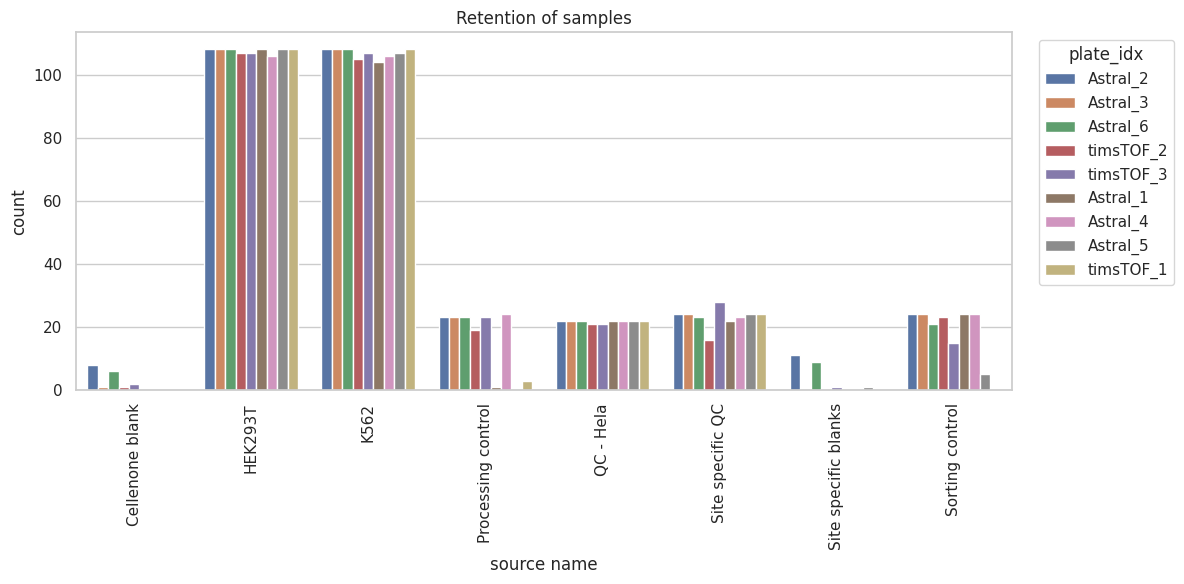

In [49]:
counts = adata_protein.obs.groupby(['source name', 'plate_idx']).size().reset_index(name='count')

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=counts, x='source name', y='count', hue='plate_idx', dodge=True)
ax.set_xlabel('source name')
ax.set_ylabel('count')
plt.xticks(rotation=90)
plt.title('Retention of samples')
plt.legend(title='plate_idx', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 3. Save

Write all four AnnData objects to `Data/AnnData/` (`.h5ad` format). The parquet files preserve the full column set for any subsequent ad-hoc queries without needing to re-parse the raw DIANN parquets.

> `convert_strings_to_categoricals=False` is set explicitly to avoid silent dtype changes that can break downstream string operations.

In [50]:
adata_precursor

AnnData object with n_obs × n_vars = 2672 × 87495
    obs: 'Run', 'sample_name', 'plate_id', 'plate_idx', 'source name', 'comment[X position]', 'comment[Y position]', 'comment[Plate Number]', 'comment[Gradient time]', 'comment[thawing timepoint]', 'comment[plate arrival]', 'injection_order', 'institute_name', 'Reinjection', 'Diameter', 'Elongation', 'Circularity', 'Doublet', 'Dividing', 'Dying', 'CellInBlank', 'comment[plate arrival]_date', 'comment[plate arrival]_time', 'comment[plate arrival]_datetime', 'comment[Gradient time]_date', 'comment[Gradient time]_time', 'comment[Gradient time]_datetime', 'instrument_type'
    var: 'Protein.Group', 'Protein.Ids', 'Protein.Names', 'Genes', 'Stripped.Sequence', 'Proteotypic', 'Modified.Sequence', 'Precursor.Charge', 'Precursor.Id', 'Precursor.Mz', 'Decoy', 'Q.Value', 'Global.Q.Value', 'Lib.Q.Value', 'PEP', 'Peptidoform.Q.Value', 'Global.Peptidoform.Q.Value', 'PG.Q.Value', 'PG.PEP', 'Global.PG.Q.Value', 'Protein.Q.Value', 'GG.Q.Value', 'Channe

In [51]:
adata_protein

AnnData object with n_obs × n_vars = 2672 × 7121
    obs: 'Run', 'sample_name', 'plate_id', 'plate_idx', 'source name', 'comment[X position]', 'comment[Y position]', 'comment[Plate Number]', 'comment[Gradient time]', 'comment[thawing timepoint]', 'comment[plate arrival]', 'injection_order', 'institute_name', 'Reinjection', 'Diameter', 'Elongation', 'Circularity', 'Doublet', 'Dividing', 'Dying', 'CellInBlank', 'comment[plate arrival]_date', 'comment[plate arrival]_time', 'comment[plate arrival]_datetime', 'comment[Gradient time]_date', 'comment[Gradient time]_time', 'comment[Gradient time]_datetime', 'instrument_type'
    var: 'Protein.Ids', 'Protein.Names', 'Genes', 'Contaminant'
    layers: 'PG.TopN', 'PG.Q.Value', 'PG.PEP', 'Global.PG.Q.Value', 'PG.MaxLFQ.Quality', 'X_log2'

In [52]:
ANNDATA_OUT = os.path.join(
    ROOT_OUT,
    'AnnData',
    'DIANN',
    'v2.6',
    # 'first_pass',
    'second_pass',
    'base'
)
Path(ANNDATA_OUT).mkdir(parents=True, exist_ok=True)

adata_precursor.write_h5ad(
    os.path.join(ANNDATA_OUT, 'adata_precursor.h5ad'),
    convert_strings_to_categoricals=False
)
adata_protein.write_h5ad(
    os.path.join(ANNDATA_OUT, 'adata_protein.h5ad'),
    convert_strings_to_categoricals=False
)
adata_precursor_qc.write_h5ad(
    os.path.join(ANNDATA_OUT, 'adata_precursor_qc.h5ad'),
    convert_strings_to_categoricals=False
)
adata_protein_qc.write_h5ad(
    os.path.join(ANNDATA_OUT, 'adata_protein_qc.h5ad'),
    convert_strings_to_categoricals=False
)